# Data Analysis of Superstore
### Internship Project Report
<div dir="rtl" style="text-align: right; direction:rtl; !important; unicode-bidi: bidi-override; font-family: Tahoma, Arial, sans-serif; font-size:15px;">
بیتا کوهستانی<br>
شماره دانشجویی: 4011154105435<br>
استاد باستان فرد<br>
عنوان پروژه: تحلیل داده و مصورسازی با پایتون<br>
تاریخ: 62\50\4041
</div>


<style>
pre, code {
    white-space: pre-wrap !important;
    word-break: break-word !important;
}
</style>


In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
#jupyter nbconvert SuperstoreAnalysis.ipynb --to html
sns.set_context('notebook', font_scale=1.2)
pd.set_option('display.max_columns', 10)
pd.set_option('display.width', 10)
pd.set_option("display.max_colwidth", 20)
warnings.filterwarnings('ignore')

# 1. Data Loading

In [44]:
store_df = pd.read_csv('Sample - Superstore.csv', index_col= 0, encoding= 'windows-1252')

# 2. Initial Exploration

In [45]:
store_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9994 entries, 1 to 9994
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       9994 non-null   object 
 1   Order Date     9994 non-null   object 
 2   Ship Date      9994 non-null   object 
 3   Ship Mode      9994 non-null   object 
 4   Customer ID    9994 non-null   object 
 5   Customer Name  9994 non-null   object 
 6   Segment        9994 non-null   object 
 7   Country        9994 non-null   object 
 8   City           9994 non-null   object 
 9   State          9994 non-null   object 
 10  Postal Code    9994 non-null   int64  
 11  Region         9994 non-null   object 
 12  Product ID     9994 non-null   object 
 13  Category       9994 non-null   object 
 14  Sub-Category   9994 non-null   object 
 15  Product Name   9994 non-null   object 
 16  Sales          9994 non-null   float64
 17  Quantity       9994 non-null   int64  
 18  Discount     

In [46]:
store_df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [47]:
store_df.shape

(9994, 20)

In [48]:
store_df.sample(10)

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,...,Product Name,Sales,Quantity,Discount,Profit
Row ID,,,,,,,,,,,
3718,CA-2016-142370,9/19/2016,9/23/2016,Standard Class,TP-21130,...,Letter Slitter,5.040,2,0.0,0.1512
8547,CA-2016-119074,3/27/2016,3/31/2016,Standard Class,DS-13180,...,Acco Flexible AC...,32.540,2,0.0,15.9446
5746,US-2017-147886,3/28/2017,3/31/2017,First Class,DH-13075,...,Stackable Trays,21.560,7,0.0,6.8992
541,CA-2014-140795,2/1/2014,2/3/2014,First Class,BD-11500,...,Enermax Aurora L...,468.900,6,0.0,206.3160
4976,CA-2015-142202,9/18/2015,9/23/2015,Second Class,JR-16210,...,Enermax Acrylux ...,717.120,9,0.2,152.3880
5768,CA-2017-126396,9/8/2017,9/12/2017,Second Class,AR-10345,...,Memorex Froggy F...,85.200,6,0.2,20.2350
3489,CA-2015-157322,7/2/2015,7/6/2015,Standard Class,RH-19600,...,Hon 4070 Series ...,408.422,2,0.3,-5.8346
3852,CA-2015-127593,9/21/2015,9/21/2015,Same Day,DH-13675,...,Deflect-o DuraMa...,85.300,2,0.0,14.5010
8562,CA-2016-132829,12/23/2016,12/26/2016,Second Class,LA-16780,...,GE General Purpo...,2.328,2,0.6,-0.7566


# 3. Clean Up

## 1. Checking for NULL Values

In [49]:
store_df.isnull().sum()

Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

## 2. Handling Duplicates

In [50]:
store_df.duplicated().sum()

np.int64(1)

In [51]:
store_df.drop_duplicates(inplace= True)
store_df.duplicated().sum()

np.int64(0)

## 3. Normalizing Product Names

In [52]:
store_df[store_df['Product Name'].str.contains(r"[^a-zA-Z0-9\s\-']", regex=True)].head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,...,Product Name,Sales,Quantity,Discount,Profit
Row ID,,,,,,,,,,,
2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,...,Hon Deluxe Fabri...,731.94,3,0.0,219.5820
6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,...,Eldon Expression...,48.86,7,0.0,14.1694
15,US-2015-118983,11/22/2015,11/26/2015,Standard Class,HP-14815,...,Holmes Replaceme...,68.81,5,0.8,-123.8580
17,CA-2014-105893,11/11/2014,11/18/2014,Standard Class,PK-19075,...,Stur-D-Stor Shel...,665.88,6,0.0,13.3176
18,CA-2014-167164,5/13/2014,5/15/2014,Second Class,AG-10270,...,Fellowes Super S...,55.50,2,0.0,9.9900


In [53]:
import re

store_df['Product Name'] = store_df['Product Name'].str.replace(r"[^a-zA-Z0-9\s\-']", '', regex=True)

store_df['Product Name'] = store_df['Product Name'].str.replace(r"\s+", ' ', regex=True).str.strip()

## 4. Converting Columns to Datetime

In [54]:
store_df['Order Date']= pd.to_datetime(store_df['Order Date'], format = "%m/%d/%Y")
store_df['Ship Date']= pd.to_datetime(store_df['Ship Date'], format = "%m/%d/%Y")
store_df['Postal Code'] = store_df['Postal Code'].astype(str)

# 4. EDA

In [55]:
for col in ['Category', 'Region', 'Segment']:
    print(f"\nValue Counts for {col}:")
    print(store_df[col].value_counts())


Value Counts for Category:
Category
Office Supplies    6026
Furniture          2120
Technology         1847
Name: count, dtype: int64

Value Counts for Region:
Region
West       3203
East       2847
Central    2323
South      1620
Name: count, dtype: int64

Value Counts for Segment:
Segment
Consumer       5191
Corporate      3020
Home Office    1782
Name: count, dtype: int64


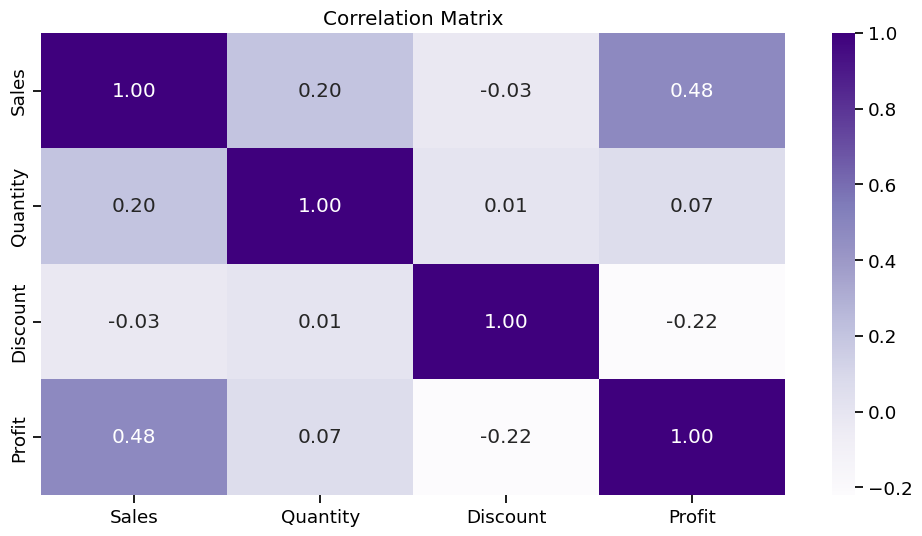

In [56]:
plt.figure(figsize=(12, 6))
sns.heatmap(store_df.corr(numeric_only=True), annot=True, cmap='Purples', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

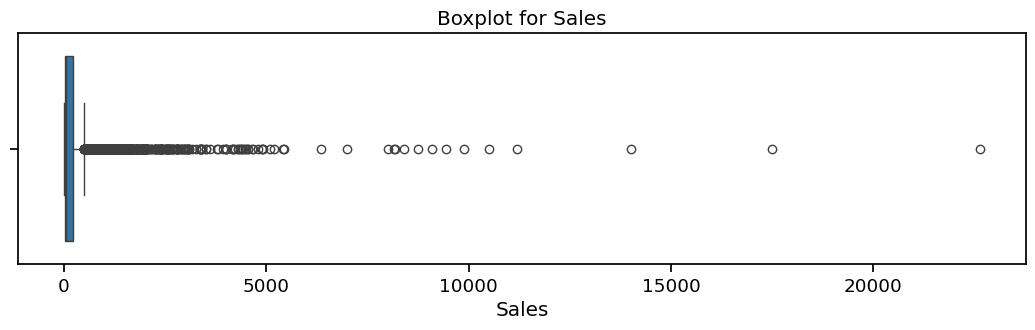

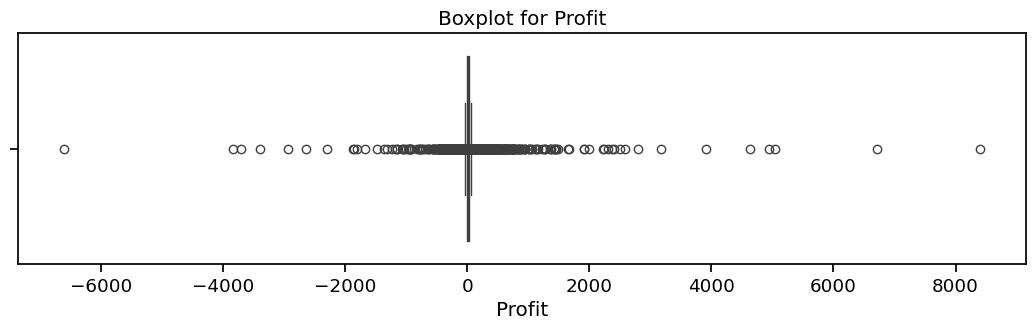

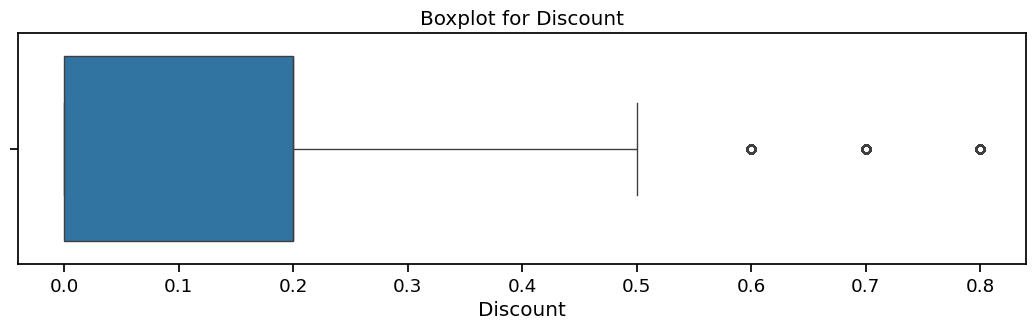

In [57]:
for col in ['Sales', 'Profit', 'Discount']:
    plt.figure(figsize=(13, 3))
    sns.boxplot(x=store_df[col])
    plt.title(f'Boxplot for {col}')
    plt.show()

## 1. Handling Outliers

In [58]:
q_low = store_df['Profit'].quantile(0.01)
q_high = store_df['Profit'].quantile(0.99)
df_clean = store_df[(store_df['Profit'] > q_low) & (store_df['Profit'] < q_high)]

# 5. Feature Engineering

In [59]:
store_df['Year Month'] = store_df['Order Date'].dt.to_period('M')
store_df['Order Year'] = store_df['Order Date'].dt.year
store_df['Order Month'] = store_df['Order Date'].dt.month

In [60]:
store_df['Profit Margin'] = store_df['Profit'] / store_df['Sales']
store_df['Shipping Time'] = (store_df['Ship Date'] - store_df['Order Date']).dt.days

# 6. Total Sales by Region

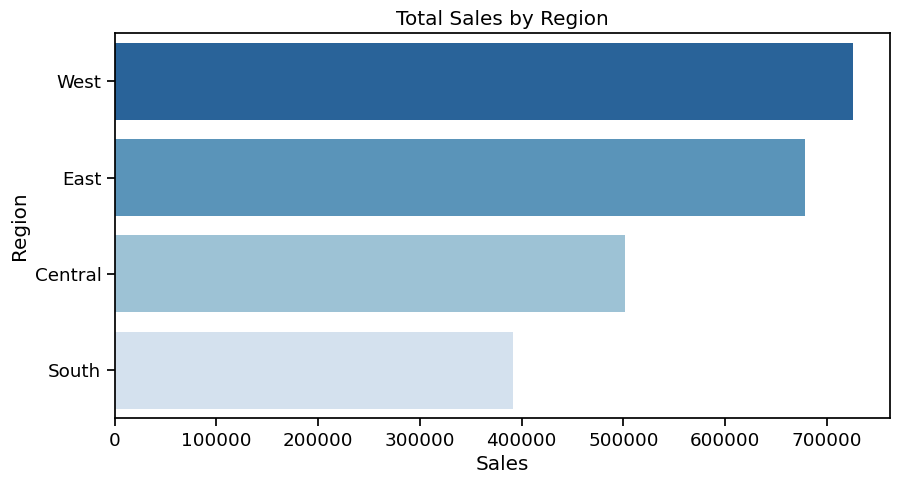

In [61]:
top_regions = store_df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,5))
sns.barplot(x=top_regions.values, y=top_regions.index, palette='Blues_r')
plt.title('Total Sales by Region')
plt.xlabel('Sales')
plt.ylabel('Region')
plt.show()

# 7. Total Profit by Region

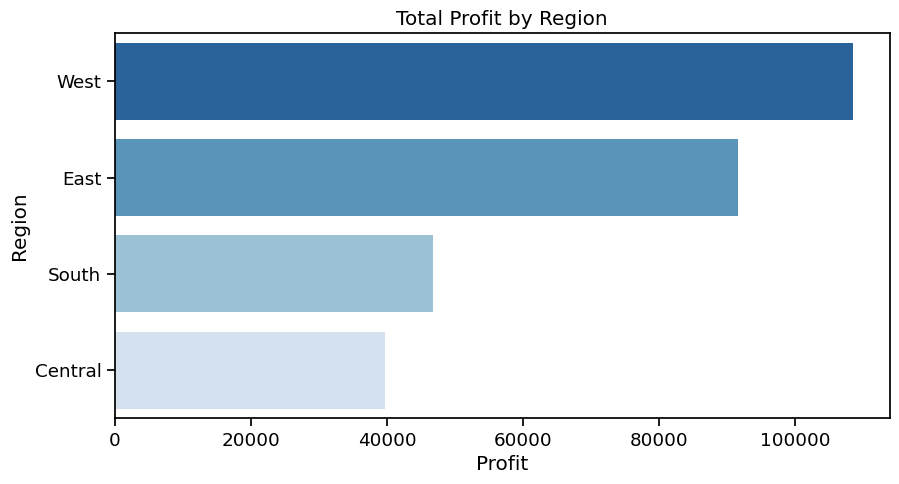

In [62]:
top_regions = store_df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,5))
sns.barplot(x=top_regions.values, y=top_regions.index, palette='Blues_r')
plt.title('Total Profit by Region')
plt.xlabel('Profit')
plt.ylabel('Region')
plt.show()

# 8. Top 10 States and Cities

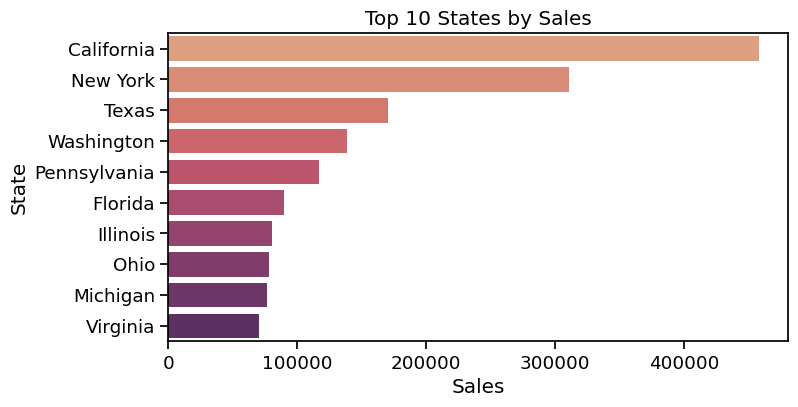

In [63]:
top_States = store_df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(8,4))
sns.barplot(x=top_States.values, y=top_States.index, palette='flare')
plt.title('Top 10 States by Sales')
plt.xlabel('Sales')
plt.ylabel('State')
plt.show()

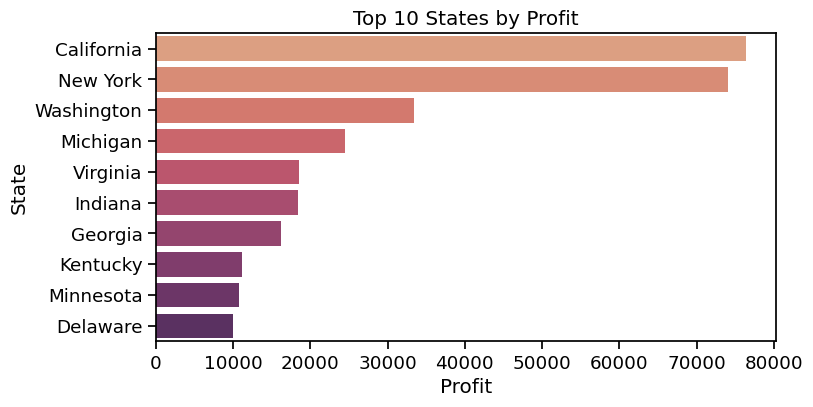

In [64]:
top_States = store_df.groupby('State')['Profit'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(8,4))
sns.barplot(x=top_States.values, y=top_States.index, palette='flare')
plt.title('Top 10 States by Profit')
plt.xlabel('Profit')
plt.ylabel('State')
plt.show()

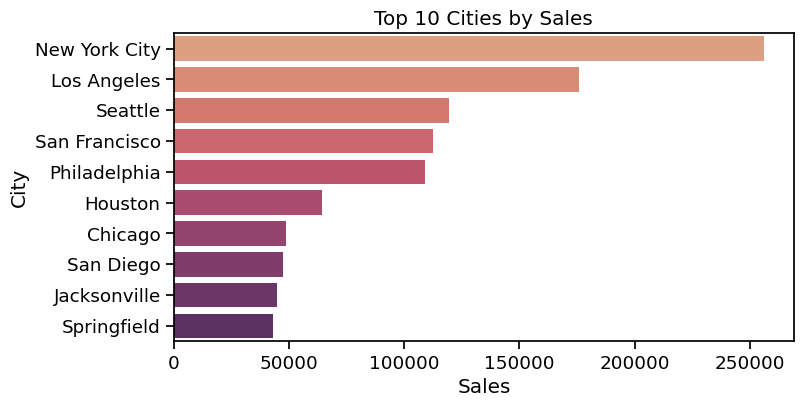

In [65]:
top_Cities = store_df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(8,4))
sns.barplot(x=top_Cities.values, y=top_Cities.index, palette='flare')
plt.title('Top 10 Cities by Sales')
plt.xlabel('Sales')
plt.ylabel('City')
plt.show()

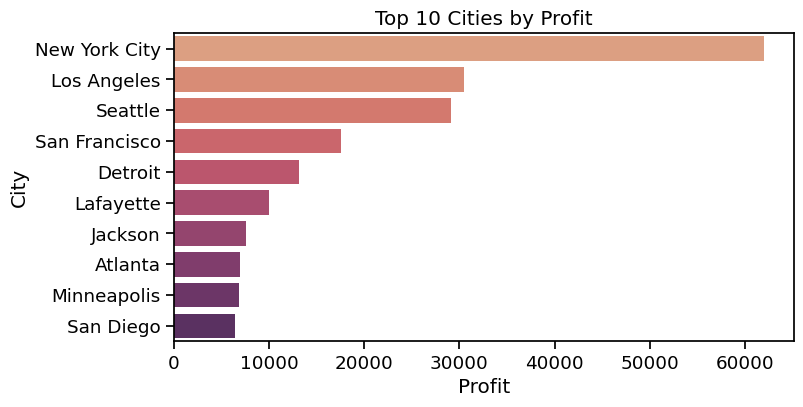

In [66]:
top_Cities = store_df.groupby('City')['Profit'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(8,4))
sns.barplot(x=top_Cities.values, y=top_Cities.index, palette='flare')
plt.title('Top 10 Cities by Profit')
plt.xlabel('Profit')
plt.ylabel('City')
plt.show()

# 9. Sales by Segment and Category

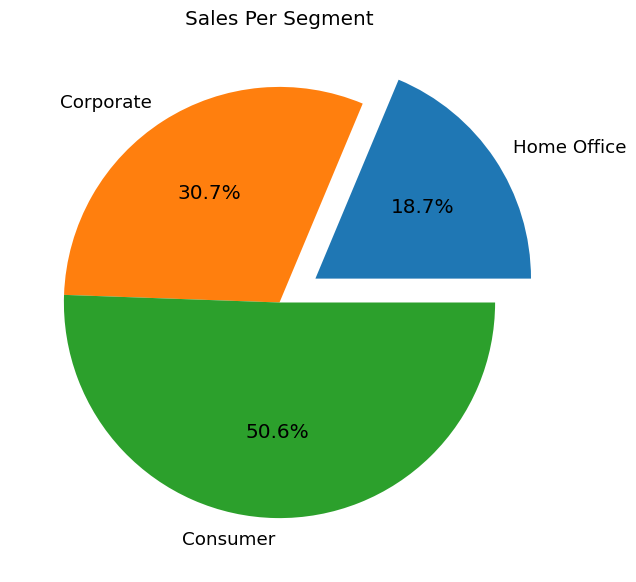

In [67]:
seg_sales = store_df.groupby('Segment')['Sales'].sum().sort_values()
plt.figure(figsize=(10,7))
seg_sales.plot(kind='pie', autopct='%1.1f%%', explode=[0.2,0,0], title='Sales Per Segment')
plt.ylabel('')
plt.show()

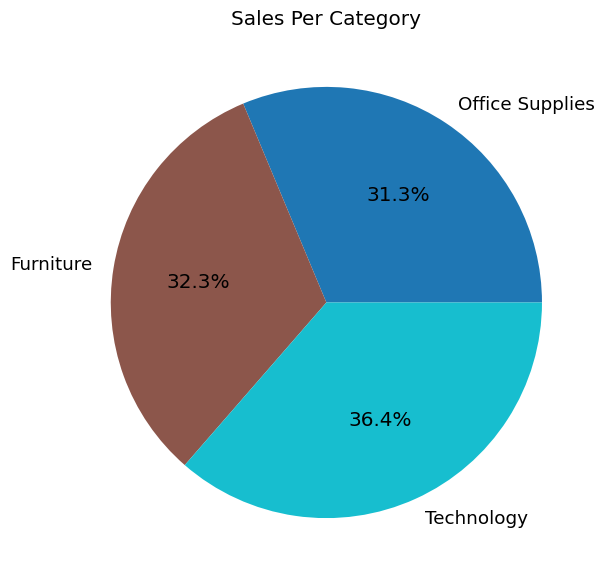

In [68]:
cat_sales = store_df.groupby('Category')['Sales'].sum().sort_values()
plt.figure(figsize=(10,7))
cat_sales.plot(kind='pie', autopct='%1.1f%%',colormap='tab10', title='Sales Per Category')
plt.ylabel('')
plt.show()

# 10. Profit by Category

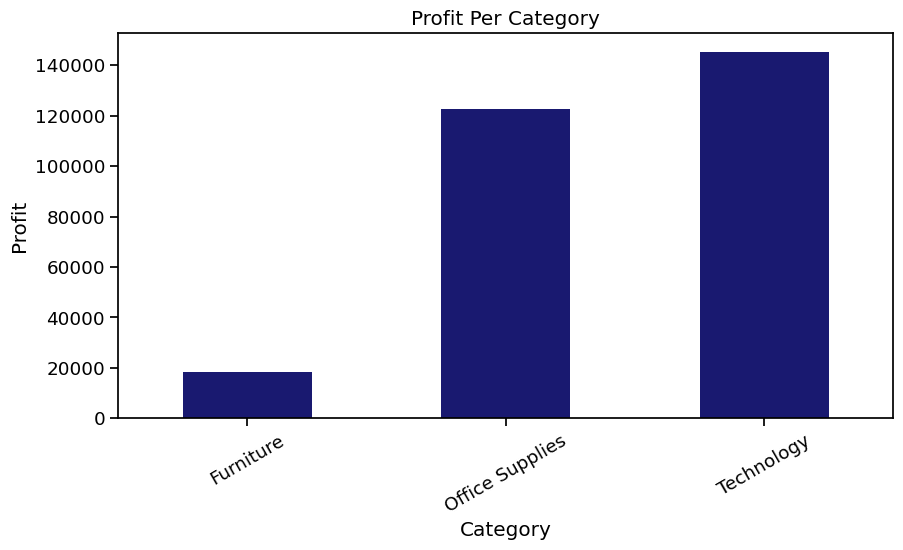

In [69]:
profit_by_category = store_df.groupby('Category')['Profit'].sum().sort_values()
plt.figure(figsize=(10,5))
profit_by_category.plot(kind='bar', color='midnightblue', title='Profit Per Category')
plt.xlabel('Category')
plt.xticks(rotation=30)
plt.ylabel('Profit')
plt.show()

# 11. Profit Margin by Category

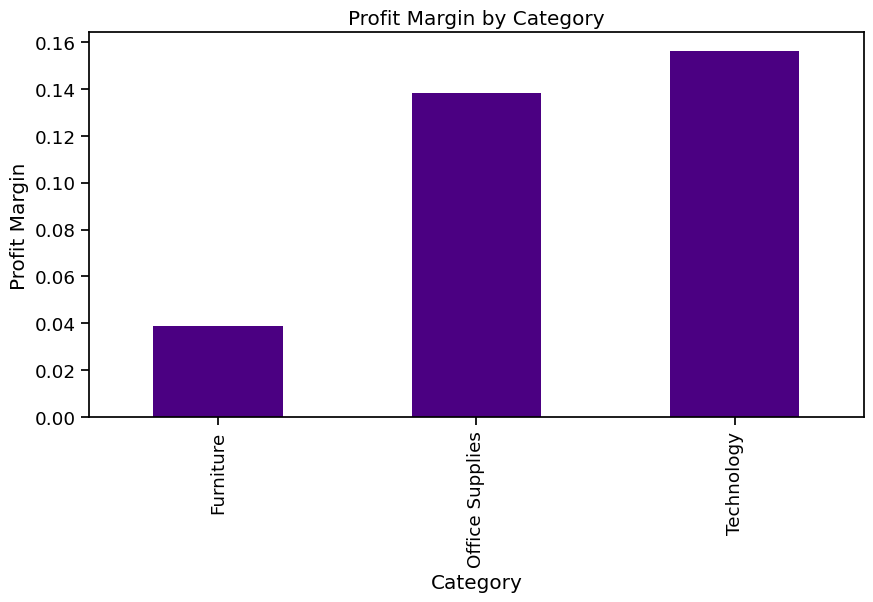

In [70]:
margin_by_category = store_df.groupby('Category')['Profit Margin'].mean().sort_values()
plt.figure(figsize=(10,5)) 
margin_by_category.plot(kind='bar', color='indigo')
plt.title('Profit Margin by Category')
plt.ylabel('Profit Margin')
plt.show()

# 12. Sales and Profit By Sub-Category

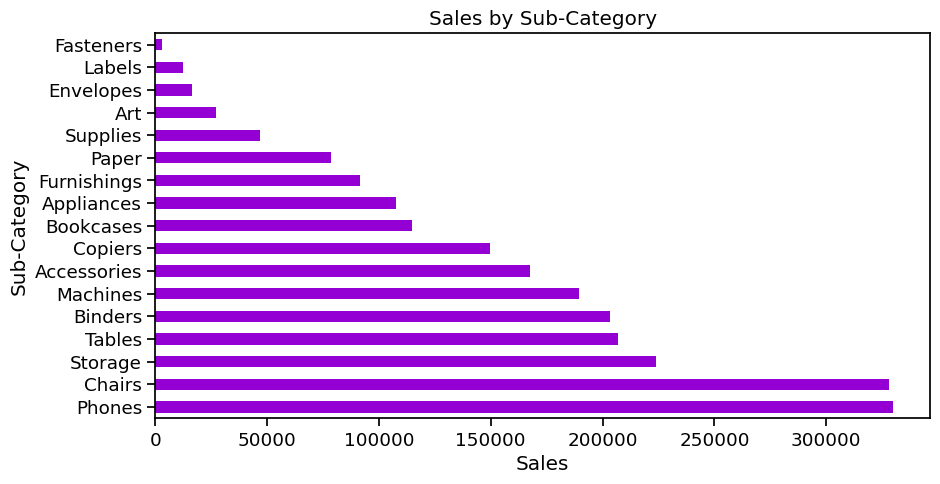

In [71]:
subcat_by_sales = store_df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,5))
subcat_by_sales.plot(kind='barh', color='darkviolet')
plt.title('Sales by Sub-Category')
plt.xlabel('Sales')
plt.ylabel('Sub-Category')
plt.show()

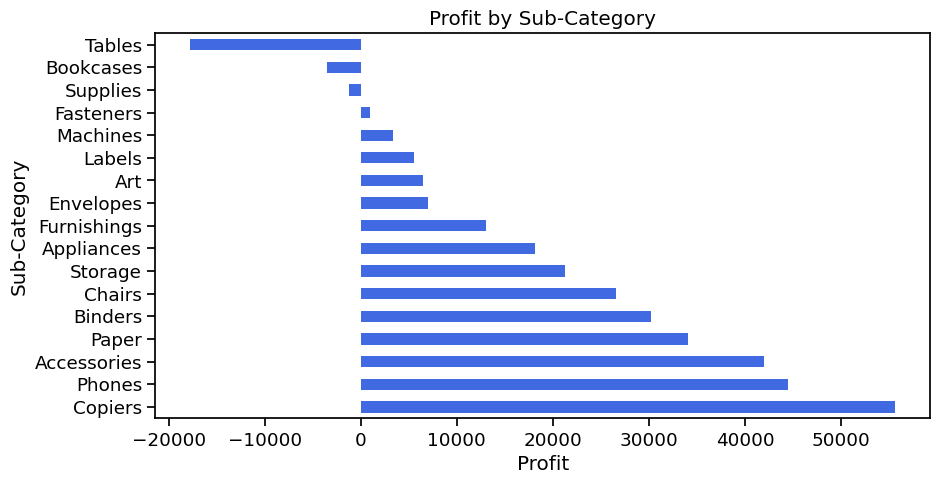

In [72]:
subcat_by_profit = store_df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,5))
subcat_by_profit.plot(kind='barh', color='royalblue')
plt.title('Profit by Sub-Category')
plt.xlabel('Profit')
plt.ylabel('Sub-Category')
plt.show()

# 13. Profit and Sales by Category and Region

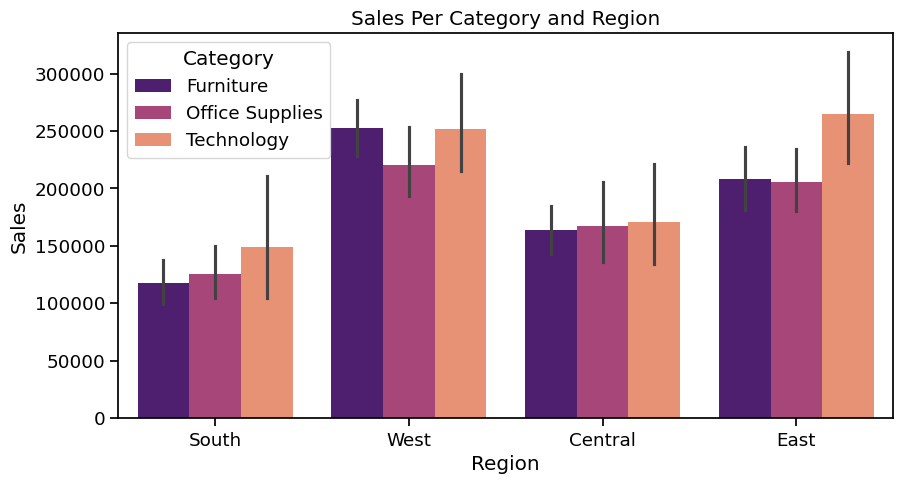

In [73]:
plt.figure(figsize=(10,5))
sns.barplot(data=store_df, x='Region', y='Sales', hue='Category', palette='magma', estimator=sum)
plt.title('Sales Per Category and Region')
plt.show()

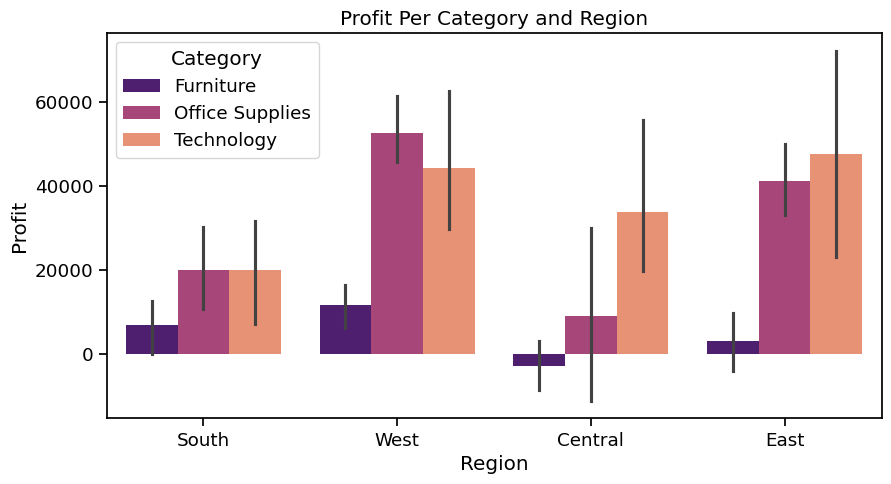

In [74]:
plt.figure(figsize=(10,5))
sns.barplot(data=store_df, x='Region', y='Profit', hue='Category', palette='magma', estimator=sum)
plt.title('Profit Per Category and Region')
plt.show()

# 14. Loss Products

Text(0.5, 0, 'Profit')

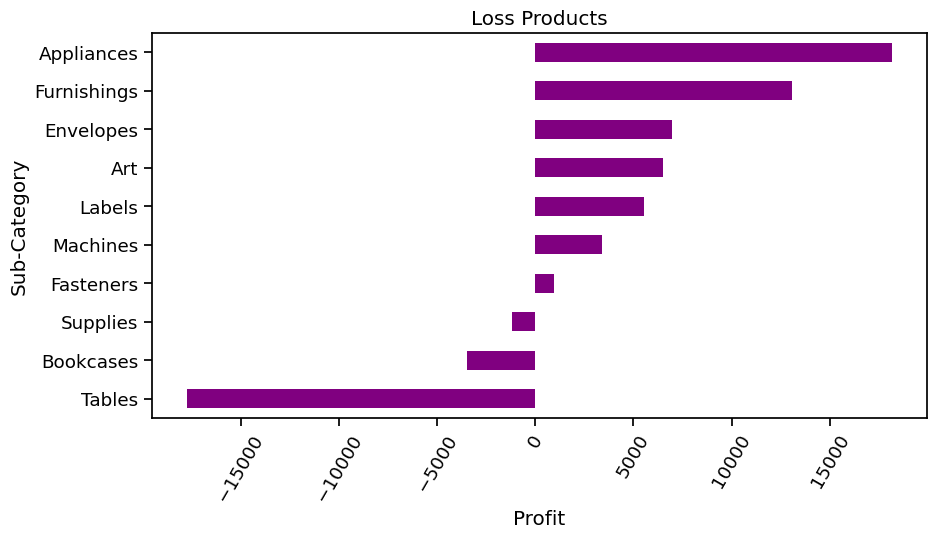

In [75]:
loss_products = store_df.groupby('Sub-Category')['Profit'].sum().sort_values().head(10)
plt.figure(figsize=(10,5))
loss_products.plot(kind='barh',color='purple', title='Loss Products')
plt.xticks(rotation=60)
plt.xlabel('Profit')

# 15. Impact of Discount on Profit

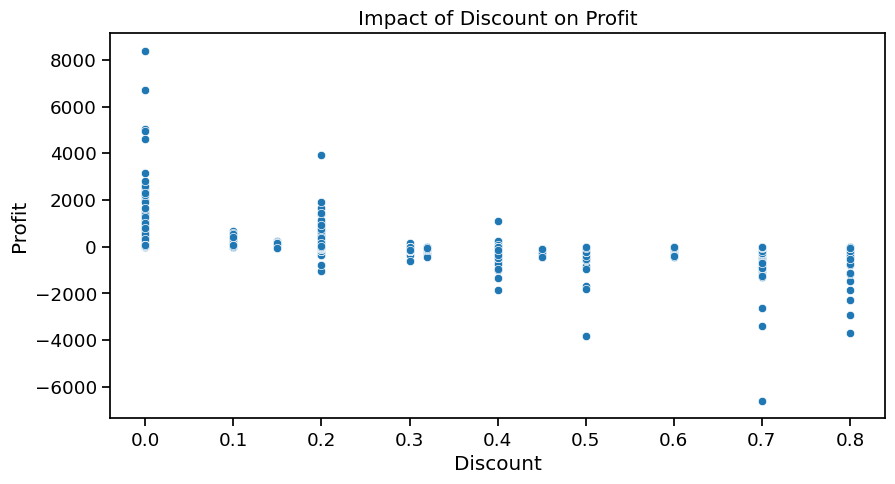

In [76]:
plt.figure(figsize=(10,5))
sns.scatterplot(x='Discount', y='Profit', data=store_df)
plt.title('Impact of Discount on Profit')
plt.show()

# 16. Discount Distribution by Sub-Category

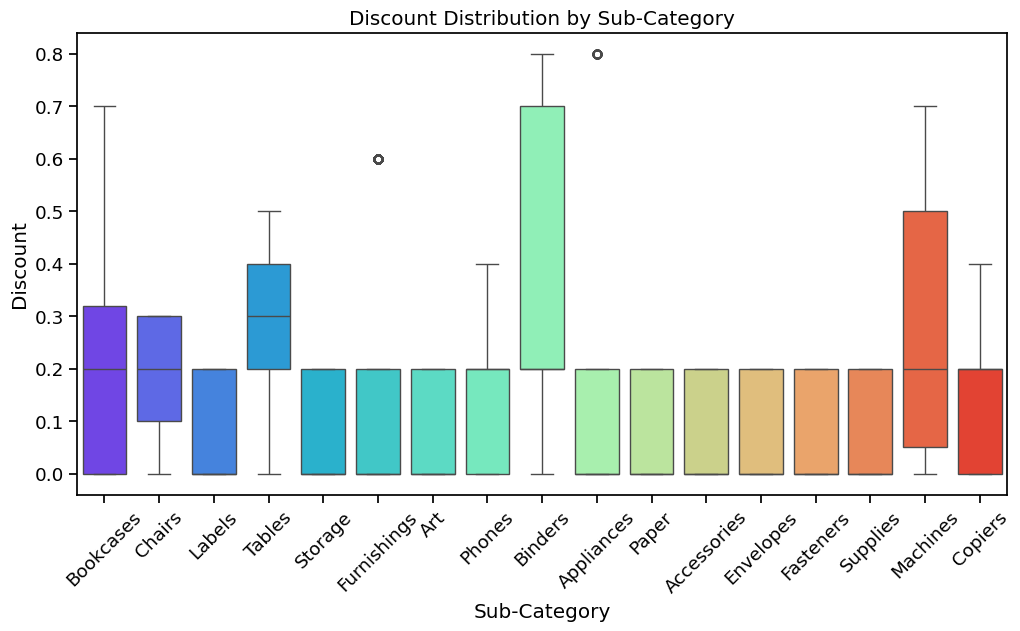

In [77]:
plt.figure(figsize=(12,6))
sns.boxplot(data=store_df, x='Sub-Category', y='Discount', palette='rainbow')
plt.xticks(rotation=45)
plt.title('Discount Distribution by Sub-Category')
plt.show()

# 17. Total Sales and Profit per Year

Text(0.5, 1.0, 'Profit Per Year')

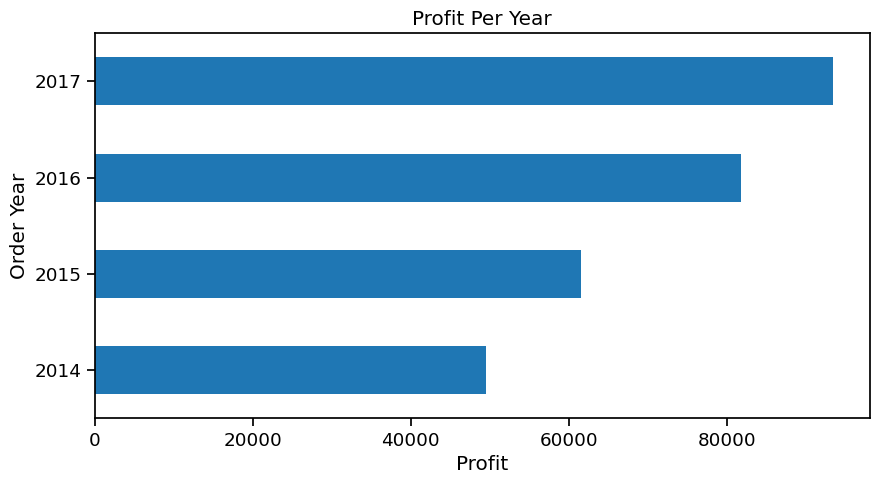

In [78]:
plt.figure(figsize=(10,5))
store_df.groupby('Order Year')['Profit'].sum().plot.barh()
plt.xlabel('Profit')
plt.title('Profit Per Year')

Text(0.5, 1.0, 'Sales Per Year')

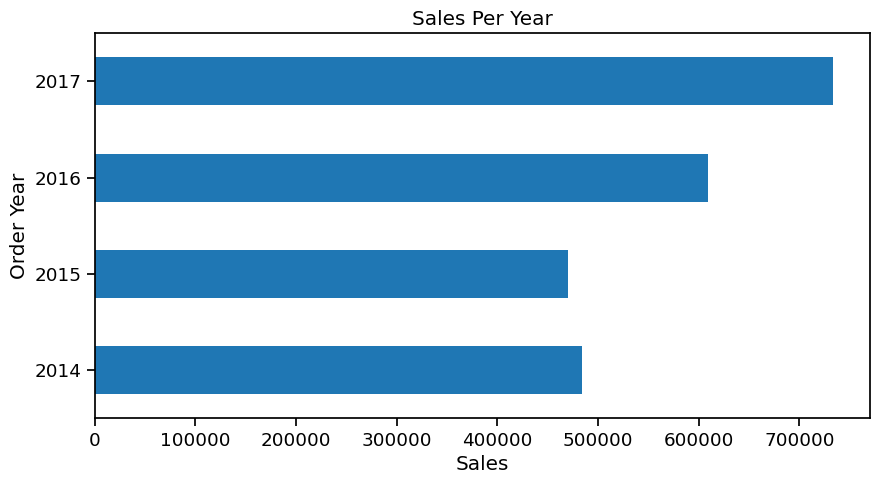

In [79]:
plt.figure(figsize=(10,5))
store_df.groupby('Order Year')['Sales'].sum().plot.barh()
plt.xlabel('Sales')
plt.title('Sales Per Year')

# 18. Monthly Sales per Year

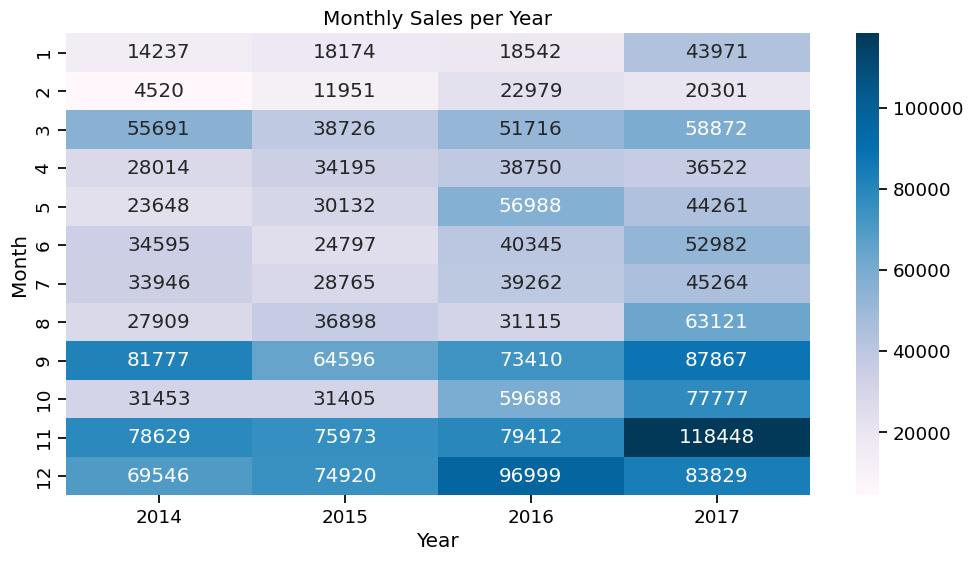

In [80]:
pivot = store_df.pivot_table(index='Order Month', columns='Order Year', values='Sales', aggfunc='sum')
plt.figure(figsize=(12,6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='PuBu')
plt.title('Monthly Sales per Year')
plt.xlabel('Year')
plt.ylabel('Month')
plt.show()

# 19. Total Sales and Profit by Month Over Time

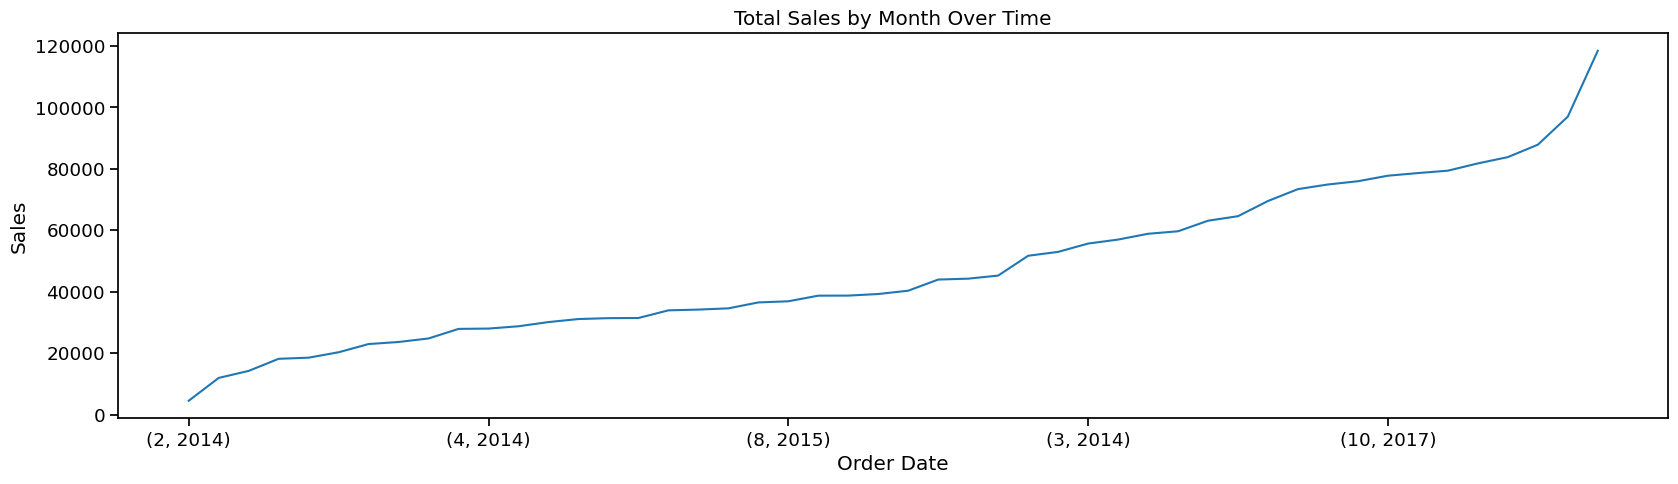

In [81]:
sales_month = store_df.groupby(['Order Month', 'Order Year'])['Sales'].sum().sort_values()
plt.figure(figsize=(20,5))
sales_month.plot()
plt.title('Total Sales by Month Over Time')
plt.xlabel('Order Date')
plt.ylabel('Sales')
plt.show()

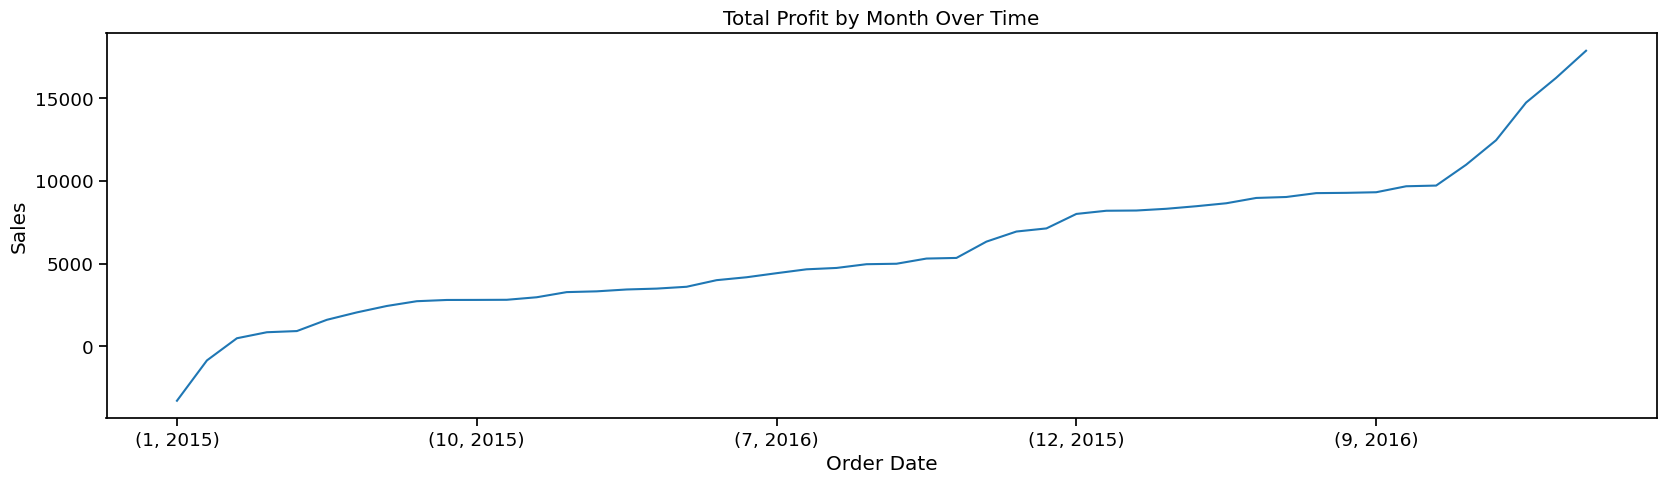

In [82]:
sales_month = store_df.groupby(['Order Month', 'Order Year'])['Profit'].sum().sort_values()
plt.figure(figsize=(20,5))
sales_month.plot()
plt.title('Total Profit by Month Over Time')
plt.xlabel('Order Date')
plt.ylabel('Sales')
plt.show()

# 20. Insights

<div dir="rtl" style="text-align: right; direction:rtl; font-family: Tahoma, Arial, sans-serif; font-size:15px;">
<b>- عملکرد جغرافیایی (شهرها و ایالت‌ها):</b><br><br>
ناحیه West بیشترین فروش و سودآوری را دارد.<br>
برخی از ایالت ها مثل Texas فروش بالاتر اما سودآوری کمتری نسبت به بقیه ایالت ها دارند که نیازمند بررسی قیمت گذاری و هزینه ی ارسال است.<br><br>
<b>- عملکرد دسته‌بندی‌ها:</b><br>
دسته ی Technology بیشترین فروش و سود آوری را دارد.<br>
دسته ی Office Supplies کمترین فروش را دارد اما پایدار است.<br>
دسته ی Furniture .با اینکه فروش بیشتری دارد اما با تفاوت زیادی سود و حاشیه سود کمتری دارد<br>
در برخی زیر دسته های Furniture مثل Tables بر خلاف فروش بالا زیان وجود دارد.<br><br>
<b>- تاثیر تخفیف بر سود:</b><br>
تخفیف های بالای 30% در اغلب موارد منجر به کاهش سود و یا حتی زیان می شود.<br><br>
<b>- روند فروش سالانه:</b><br>
فروش و سود در سال های اخیر روند صعودی داشته اند.<br>
نوسانات ماهانه مشهود است.<br>
ماه های پایانی سال به دلیل تعطیلات و سال نو افزایش فروش داشته اند و پرفروش ترین ماه ها هستند.<br>
در برخی از ماه ها مثل ژانویه و فوریه به دلیل فصل کم تقاضا افت محسوس فروش مشاهده می شود.
</div>

# 21. Recommendations

<div dir="rtl" style="text-align: right; direction:rtl; font-family: Tahoma, Arial, sans-serif; font-size:15px;">
<b>-مدیریت تخفیف‌ ها</b><br>
اجتناب از تخفیف‌ های بیش از 30% مگر در شرایط انبارگردانی یا کمپین‌ های خاص.<br>
تحلیل اثر تخفیف در سطح هر زیردسته برای بهینه‌ سازی قیمت‌ گذاری.<br><br>
<b>-تمرکز بر دسته‌های سودآور</b><br>
بازبینی سیاست‌های فروش و قیمت‌گذاری در دسته‌ی Furniture، به‌ خصوص محصولات کم‌ سود یا زیان آور.<br><br>
<b>-استراتژی جغرافیایی</b><br>
توسعه فعالیت در ایالت‌ ها و شهرهای با فروش و سود بالا.<br>
بررسی دلایل سود پایین در مناطق با فروش بالا و رفع موانع (هزینه ارسال، رقابت قیمتی، خدمات پس از فروش).
</div>